# Modeling - Predicting Incident-Prone Alerts

The goal here is straightforward: given an alert's configuration (what it monitors, its threshold, how it's set up), can we predict whether it's likely to lead to a real incident?

The target variable is derived from real PagerDuty incident data - alerts whose product+service combination triggered actionable pages (≤10 incidents in a 29-day window, filtering out chronic noise). This gives us a clean signal of "this alert configuration led to a real problem that required human response."

We'll train and compare four models:
1. **Logistic Regression** - simple, interpretable, good baseline for understanding feature coefficients
2. **Random Forest** - handles nonlinear relationships, gives us feature importance
3. **Gradient Boosting** - typically the strongest performer on tabular data
4. **XGBoost** - state-of-the-art gradient boosting with built-in handling for class imbalance

All models get the same treatment: StandardScaler where appropriate, StratifiedKFold cross-validation (because the classes are imbalanced at ~11:1), and GridSearchCV for hyperparameter tuning.

## Setup

In [48]:
import os, re, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, average_precision_score,
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline

# XGBoost is not part of the standard course curriculum but is widely used
# in industry for tabular classification. Reference: https://xgboost.readthedocs.io/
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — run `pip install xgboost` to enable it.")

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
os.chdir(os.path.join(os.path.expanduser('~'), 'Documents', 'MLandAI', 'capstone'))

## Load and Prepare Data

Reusing the same cleaning and feature engineering from the EDA notebook. Keeping this self-contained so the notebook runs independently.

In [49]:
df_raw = pd.read_csv('data/argus_alerts_v2_masked.csv')
df = df_raw.drop_duplicates(subset=['alert_id', 'trigger_id']).copy()
print(f"Working with {len(df):,} rows after dedup")

Working with 45,961 rows after dedup


In [50]:
# --- Feature engineering (same logic as EDA) ---

# Parse dates
df['created_date'] = pd.to_datetime(df['created_date'], format='ISO8601', utc=True)
df['modified_date'] = pd.to_datetime(df['modified_date'], format='ISO8601', utc=True)
df['alert_age_days'] = (df['modified_date'] - df['created_date']).dt.days

# Metric category from expression
metric_rules = [
    ('apdex',           r'apdex'),
    ('apm_duration',    r'apm_duration|latency|_p50_|_p95_|_p99_|cpa_duration'),
    ('error_rate',      r'error.rate|error_rate|apm_error|err_count|status_code|5xx|4xx|apm_\[request\|response\]_count'),
    ('request_rate',    r'request_rate|req.rate|throughput|RequestCount|apm_request_count'),
    ('cpu',             r'[Cc][Pp][Uu]|cpu_usage_seconds'),
    ('memory',          r'[Mm]emory|RSS|heap|MemoryUtilization|oomkilled|OOMKilled'),
    ('disk',            r'[Dd]isk|volume|percent_bytes\.free'),
    ('rds_database',    r'rds|RDS|DatabaseConnections|DiskQueueDepth|FreeableMemory'),
    ('redis_cache',     r'redis|elasticache|Redis|Elasticache'),
    ('queue_backlog',   r'[Qq]ueue|backlog|SQS|dlq|dead_letter'),
    ('availability',    r'availability|uptime|health'),
    ('pod_restart',     r'pod.restart|restart_count|CrashLoopBackOff|kube_pod_container_status_restarts'),
    ('network',         r'[Nn]etwork|[Bb]andwidth|PacketsIn|PacketsOut|nginx|connections_accepted'),
    ('synthetic',       r'synthetic'),
    ('kube_infra',      r'kube_daemonset|kube_deployment|kube_statefulset|kube_node'),
    ('anomaly',         r'sqlQuery|formattedSQL|anomaly'),
    ('jvm',             r'jvm|gc_pause|GarbageCollection'),
]

def classify_metric(expr):
    if pd.isna(expr):
        return 'unknown'
    for name, pattern in metric_rules:
        if re.search(pattern, expr):
            return name
    return 'other'

df['metric_category'] = df['expression'].apply(classify_metric)

# Environment
def extract_environment(name):
    name_lower = str(name).lower()
    if any(x in name_lower for x in ['kstg', '-stg', '.stg', '_stg', 'staging']):
        return 'staging'
    elif any(x in name_lower for x in ['-prod', '.prod', '_prod', 'prod1', 'prod2', 'prod3']):
        return 'production'
    elif any(x in name_lower for x in ['-dev', '.dev', '_dev', 'mdev']):
        return 'development'
    elif any(x in name_lower for x in ['-uat', '.uat']):
        return 'uat'
    elif any(x in name_lower for x in ['-perf', '.perf', '-qa', '.qa', 'kqa']):
        return 'qa'
    return 'production'

df['environment'] = df['alert_name'].apply(extract_environment)

# Check interval from cron
def cron_to_minutes(cron):
    m = re.match(r'\*/?(\d+)', str(cron))
    if m:
        return int(m.group(1))
    if str(cron).startswith('0 '):
        return 60
    return None

df['check_interval_min'] = df['cron_entry'].apply(cron_to_minutes)

# Notification count
df['notification_count'] = df['notification_names'].str.count(';') + 1
df.loc[df['notification_names'].isna(), 'notification_count'] = 0

print(f"Features engineered. Shape: {df.shape}")

Features engineered. Shape: (45961, 36)


## Define the Target Variable

The target is derived from real PagerDuty incident data (2,035 incidents over 29 days, May–June 2026). An alert is labeled "incident-prone" if its product+service combination triggered actionable PD pages.

We filter to alerts with ≤10 incidents in the observation window to separate genuine incidents from chronic noise (e.g., one memory alert that fired 832 times - that's a misconfiguration, not 832 distinct problems).

This gives us ~3,800 positives vs ~42,000 negatives (11:1 imbalance) - significantly better than the previous 59:1 proxy target based on triggered_count.

In [51]:
# =============================================================
# TARGET DEFINITION — derived from PagerDuty incident data
# =============================================================
df['target'] = df['target_incident'].fillna(0).astype(int)

print(f"Target: product+service linked to actionable PD incidents (≤10/month)")
print(f"\nClass distribution:")
print(df['target'].value_counts())
print(f"\nImbalance ratio: {df['target'].value_counts()[0] / df['target'].value_counts()[1]:.1f}:1")

Target: product+service linked to actionable PD incidents (≤10/month)

Class distribution:
target
0    42156
1     3805
Name: count, dtype: int64

Imbalance ratio: 11.1:1


## Prepare Feature Matrix

Encoding categorical variables and splitting into train/test. Using stratified split to preserve the class ratio in both sets.

In [52]:
# Features I'am using
# Note: triggered_count is now a legitimate feature (no longer leaks into the target)
numeric_features = ['threshold', 'inertia_ms', 'check_interval_min',
                    'notification_count', 'alert_age_days', 'triggered_count']
binary_features = ['enabled', 'has_pagerduty']
categorical_features = ['metric_category', 'environment', 'trigger_type']

# Drop rows with missing values in our feature set
all_features = numeric_features + binary_features + categorical_features
df_model = df.dropna(subset=all_features).copy()
print(f"Rows available for modeling: {len(df_model):,} (dropped {len(df) - len(df_model):,} with missing values)")

# Encode categoricals
le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    le_dict[col] = le

# Build X and y
feature_columns = numeric_features + binary_features + [c + '_enc' for c in categorical_features]
X = df_model[feature_columns].copy()
X['enabled'] = X['enabled'].astype(int)
X['has_pagerduty'] = X['has_pagerduty'].astype(int)
y = df_model['target']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

Rows available for modeling: 45,290 (dropped 671 with missing values)

Train: 36,232 | Test: 9,058
Train positive rate: 0.084 | Test positive rate: 0.084


## Evaluation Strategy

With an ~11:1 class imbalance, accuracy is still misleading - a model that predicts "no incident" for everything scores ~92%. Instead I focus on:

- **Weighted F1-score**: balances precision and recall while accounting for class sizes
- **Precision-Recall AUC**: more informative than ROC-AUC for imbalanced problems (see Davis & Goadrich, 2006)
- **Recall on the positive class**: in this domain, missing a real incident-prone alert is worse than a false alarm

We use 5-fold StratifiedKFold to make sure each fold preserves the class ratio.

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# I'll collect results here for comparison at the end
results = []

## Model 1: Logistic Regression

Starting with the simplest model. Logistic Regression gives us interpretable coefficients - we can see exactly which features push an alert toward being "incident-prone" and by how much. It needs scaled features to work properly with regularization.

In [54]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

lr_params = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['saga']
}

lr_grid = GridSearchCV(
    lr_pipe, lr_params, cv=cv, scoring='f1_weighted', n_jobs=-1, return_train_score=True
)

start = time.time()
lr_grid.fit(X_train, y_train)
lr_time = time.time() - start

print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV F1 (weighted): {lr_grid.best_score_:.4f}")
print(f"Training time: {lr_time:.1f}s")

Best params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Best CV F1 (weighted): 0.7300
Training time: 10.8s


In [55]:
lr_pred = lr_grid.predict(X_test)
lr_proba = lr_grid.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred, target_names=['Not Incident-Prone', 'Incident-Prone']))

lr_report = classification_report(y_test, lr_pred, output_dict=True)
results.append({
    'Model': 'Logistic Regression',
    'CV F1 (weighted)': lr_grid.best_score_,
    'Test F1 (weighted)': f1_score(y_test, lr_pred, average='weighted'),
    'Test Recall (positive)': lr_report['1']['recall'],
    'Test Precision (positive)': lr_report['1']['precision'],
    'PR-AUC': average_precision_score(y_test, lr_proba),
    'Training Time (s)': lr_time
})

                    precision    recall  f1-score   support

Not Incident-Prone       0.96      0.65      0.77      8298
    Incident-Prone       0.15      0.67      0.24       760

          accuracy                           0.65      9058
         macro avg       0.55      0.66      0.51      9058
      weighted avg       0.89      0.65      0.73      9058



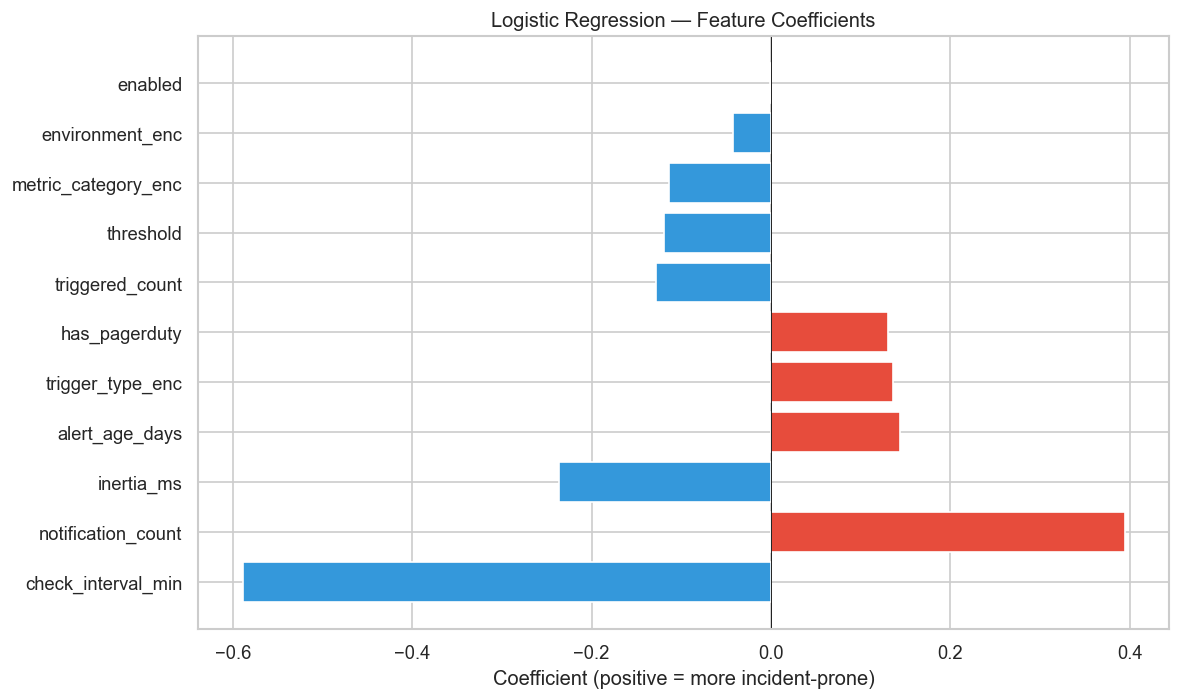

In [56]:
# Feature coefficients — what's driving the prediction?
lr_model = lr_grid.best_estimator_.named_steps['clf']
coef_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (positive = more incident-prone)')
ax.set_title('Logistic Regression — Feature Coefficients')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Model 2: Random Forest

Random Forest builds many decision trees on random subsets of the data and averages their predictions. It handles nonlinear relationships and interactions between features without needing explicit feature engineering. Also gives us a different angle on feature importance through Gini impurity.

In [57]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=cv, scoring='f1_weighted', n_jobs=-1, return_train_score=True
)

start = time.time()
rf_grid.fit(X_train, y_train)
rf_time = time.time() - start

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV F1 (weighted): {rf_grid.best_score_:.4f}")
print(f"Training time: {rf_time:.1f}s")

Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV F1 (weighted): 0.8792
Training time: 18.6s


In [58]:
rf_pred = rf_grid.predict(X_test)
rf_proba = rf_grid.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, target_names=['Not Incident-Prone', 'Incident-Prone']))

rf_report = classification_report(y_test, rf_pred, output_dict=True)
results.append({
    'Model': 'Random Forest',
    'CV F1 (weighted)': rf_grid.best_score_,
    'Test F1 (weighted)': f1_score(y_test, rf_pred, average='weighted'),
    'Test Recall (positive)': rf_report['1']['recall'],
    'Test Precision (positive)': rf_report['1']['precision'],
    'PR-AUC': average_precision_score(y_test, rf_proba),
    'Training Time (s)': rf_time
})

                    precision    recall  f1-score   support

Not Incident-Prone       0.99      0.85      0.91      8298
    Incident-Prone       0.35      0.86      0.50       760

          accuracy                           0.85      9058
         macro avg       0.67      0.86      0.71      9058
      weighted avg       0.93      0.85      0.88      9058



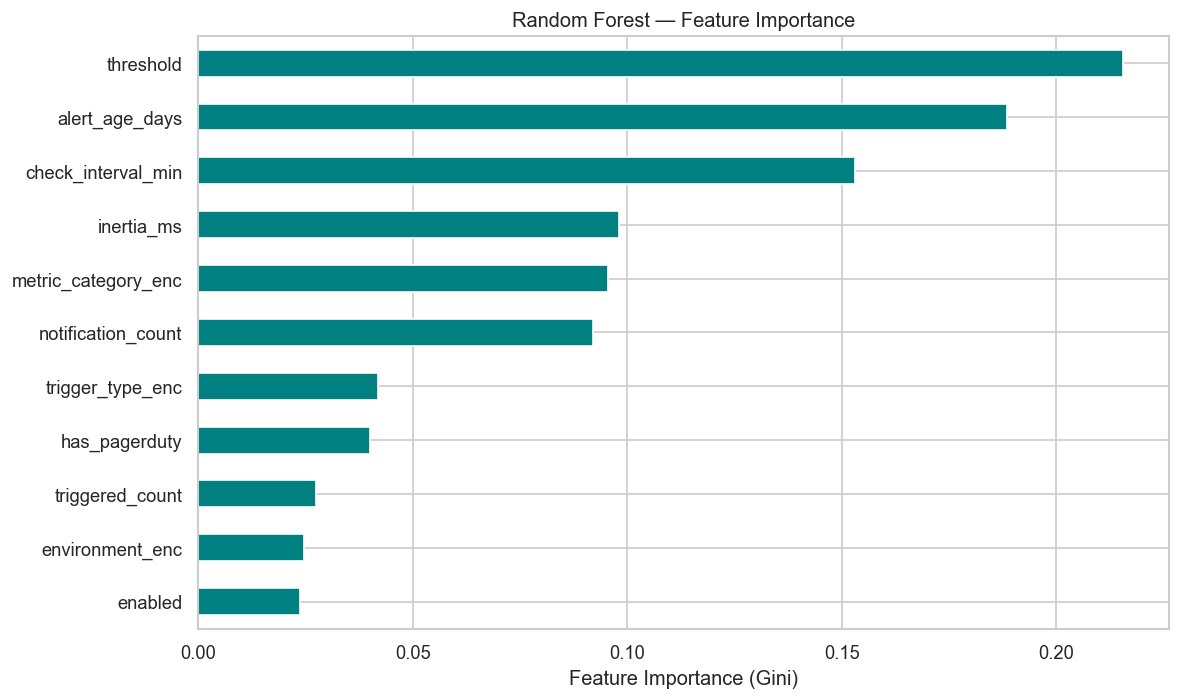

In [59]:
# Feature importance from Random Forest
rf_importance = pd.Series(
    rf_grid.best_estimator_.feature_importances_, index=feature_columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
rf_importance.plot(kind='barh', color='teal', ax=ax)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

## Model 3: Gradient Boosting

Gradient Boosting builds trees sequentially - each new tree focuses on the mistakes the previous ones made. This usually gives better results than Random Forest on structured data, though it's slower to train and more prone to overfitting if you're not careful with the learning rate.

In [60]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=cv, scoring='f1_weighted', n_jobs=-1, return_train_score=True
)

start = time.time()
gb_grid.fit(X_train, y_train)
gb_time = time.time() - start

print(f"Best params: {gb_grid.best_params_}")
print(f"Best CV F1 (weighted): {gb_grid.best_score_:.4f}")
print(f"Training time: {gb_time:.1f}s")

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1 (weighted): 0.9468
Training time: 47.7s


In [61]:
gb_pred = gb_grid.predict(X_test)
gb_proba = gb_grid.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_pred, target_names=['Not Incident-Prone', 'Incident-Prone']))

gb_report = classification_report(y_test, gb_pred, output_dict=True)
results.append({
    'Model': 'Gradient Boosting',
    'CV F1 (weighted)': gb_grid.best_score_,
    'Test F1 (weighted)': f1_score(y_test, gb_pred, average='weighted'),
    'Test Recall (positive)': gb_report['1']['recall'],
    'Test Precision (positive)': gb_report['1']['precision'],
    'PR-AUC': average_precision_score(y_test, gb_proba),
    'Training Time (s)': gb_time
})

                    precision    recall  f1-score   support

Not Incident-Prone       0.96      0.99      0.97      8298
    Incident-Prone       0.84      0.52      0.65       760

          accuracy                           0.95      9058
         macro avg       0.90      0.76      0.81      9058
      weighted avg       0.95      0.95      0.95      9058



## Model 4: XGBoost

XGBoost is an optimized gradient boosting library that's become the go-to for tabular ML competitions and industry applications. It has a built-in `scale_pos_weight` parameter that directly addresses class imbalance by weighting the minority class higher during training.

> **Note**: XGBoost is not covered in the standard course curriculum but is widely used in practice. It extends the gradient boosting concepts from Module 20.  
> Reference: Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. https://arxiv.org/abs/1603.02754

In [62]:
if HAS_XGB:
    # scale_pos_weight = number of negatives / number of positives
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_ratio = neg_count / pos_count

    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1],
        'scale_pos_weight': [1, scale_ratio],
        'subsample': [0.8]
    }

    xgb_grid = GridSearchCV(
        XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            random_state=RANDOM_STATE, verbosity=0
        ),
        xgb_params, cv=cv, scoring='f1_weighted', n_jobs=-1, return_train_score=True
    )

    start = time.time()
    xgb_grid.fit(X_train, y_train)
    xgb_time = time.time() - start

    print(f"Best params: {xgb_grid.best_params_}")
    print(f"Best CV F1 (weighted): {xgb_grid.best_score_:.4f}")
    print(f"Training time: {xgb_time:.1f}s")
else:
    print("Skipping XGBoost — not installed.")

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Best CV F1 (weighted): 0.9426
Training time: 4.1s


In [63]:
if HAS_XGB:
    xgb_pred = xgb_grid.predict(X_test)
    xgb_proba = xgb_grid.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, xgb_pred, target_names=['Not Incident-Prone', 'Incident-Prone']))

    xgb_report = classification_report(y_test, xgb_pred, output_dict=True)
    results.append({
        'Model': 'XGBoost',
        'CV F1 (weighted)': xgb_grid.best_score_,
        'Test F1 (weighted)': f1_score(y_test, xgb_pred, average='weighted'),
        'Test Recall (positive)': xgb_report['1']['recall'],
        'Test Precision (positive)': xgb_report['1']['precision'],
        'PR-AUC': average_precision_score(y_test, xgb_proba),
        'Training Time (s)': xgb_time
    })

                    precision    recall  f1-score   support

Not Incident-Prone       0.95      0.99      0.97      8298
    Incident-Prone       0.84      0.47      0.61       760

          accuracy                           0.95      9058
         macro avg       0.90      0.73      0.79      9058
      weighted avg       0.94      0.95      0.94      9058



## Model Comparison

Let's put all four models side by side and see which one actually performs best. Remember - the weighted F1 is our primary metric, but we also care about recall on the positive class because missing a real incident-prone alert has a higher cost than a false alarm.

In [64]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
results_df

,CV F1 (weighted),Test F1 (weighted),Test Recall (positive),Test Precision (positive),PR-AUC,Training Time (s)
Model,,,,,,
Logistic Regression,0.7300,0.7289,0.6658,0.1483,0.1841,10.7665
Random Forest,0.8792,0.8794,0.8618,0.3493,0.6764,18.5635
Gradient Boosting,0.9468,0.9467,0.5237,0.8432,0.7712,47.6900
XGBoost,0.9426,0.9417,0.4724,0.8447,0.7423,4.1103


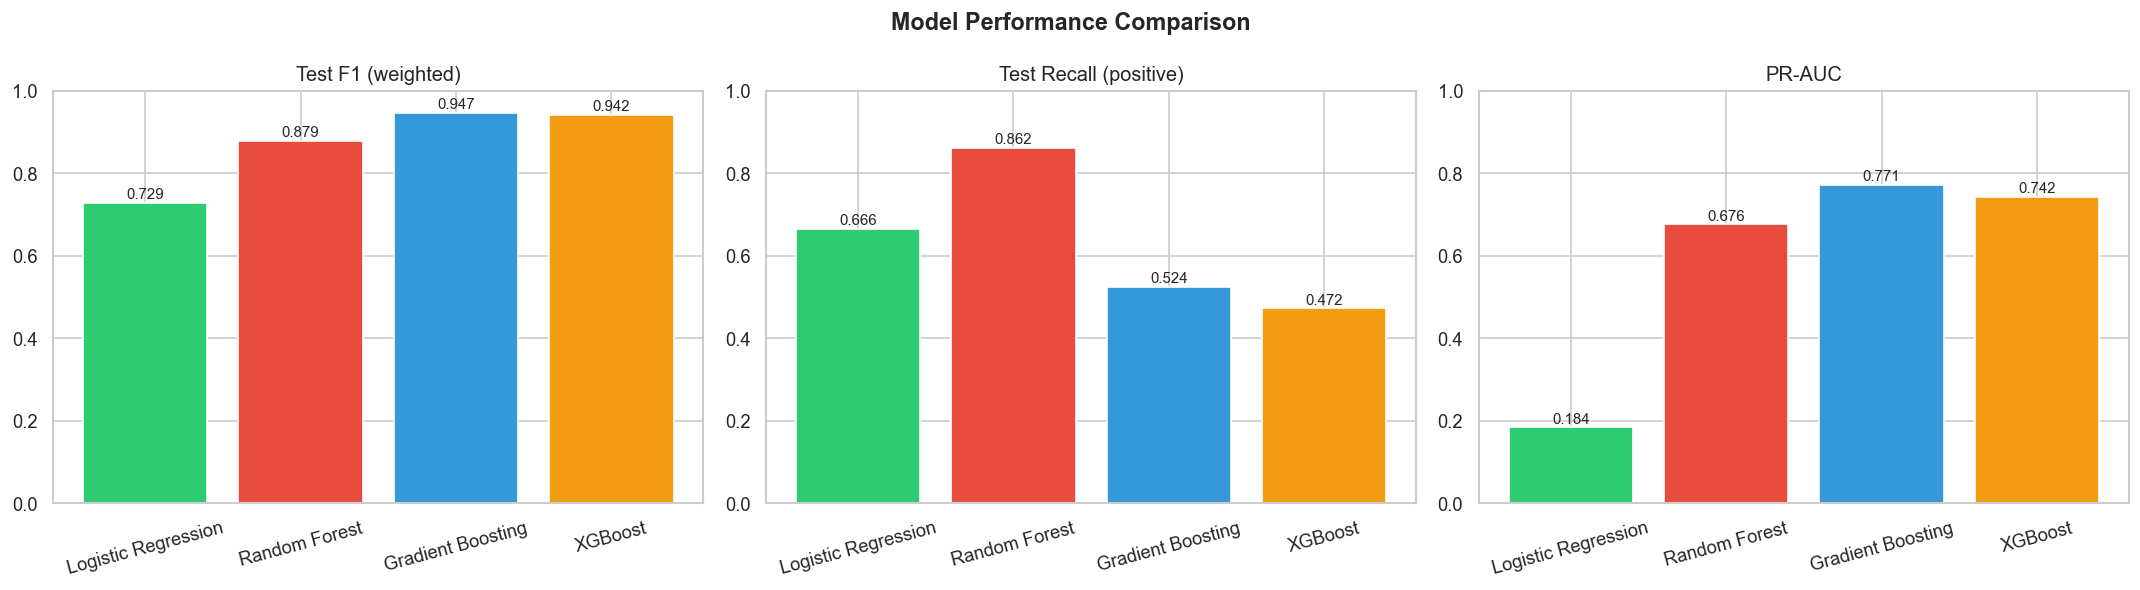

In [65]:
# Visual comparison of the key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['Test F1 (weighted)', 'Test Recall (positive)', 'PR-AUC']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors[:len(results_df)])
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                     f'{height:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Precision-Recall Curves

For imbalanced datasets, Precision-Recall curves give a much clearer picture than ROC curves. The area under the PR curve (AP score) tells us how well the model ranks positive examples above negative ones. A random classifier would have an AP equal to the prevalence (~1.7% here), so anything above that is meaningful.

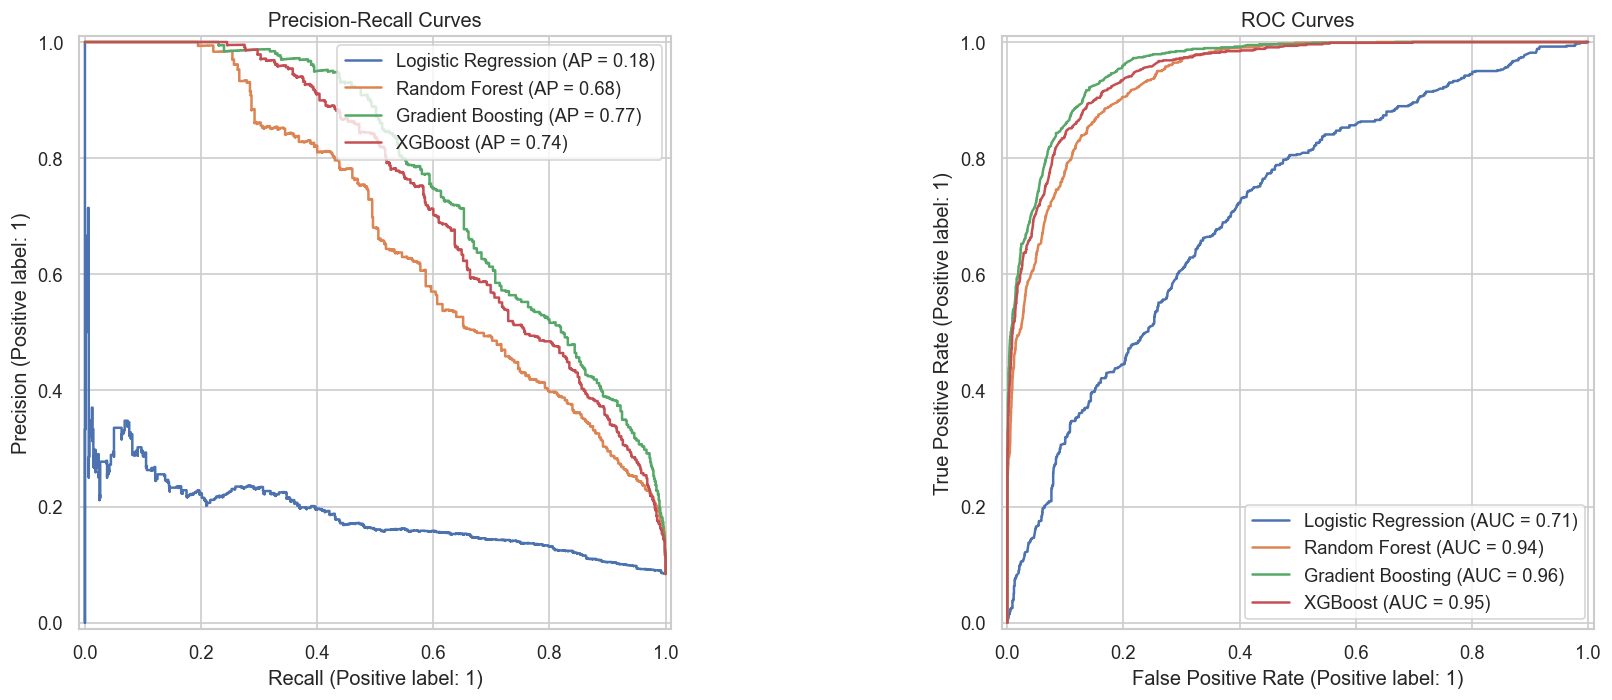

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision-Recall curves
PrecisionRecallDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, gb_proba, name='Gradient Boosting', ax=axes[0])
if HAS_XGB:
    PrecisionRecallDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=axes[0])
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(loc='upper right')

# ROC curves for reference
RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=axes[1])
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[1])
RocCurveDisplay.from_predictions(y_test, gb_proba, name='Gradient Boosting', ax=axes[1])
if HAS_XGB:
    RocCurveDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=axes[1])
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('images/pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrices

Side-by-side confusion matrices to see the tradeoffs each model makes between false positives ("flagged as risky but wasn't") and false negatives ("missed a real incident-prone alert").

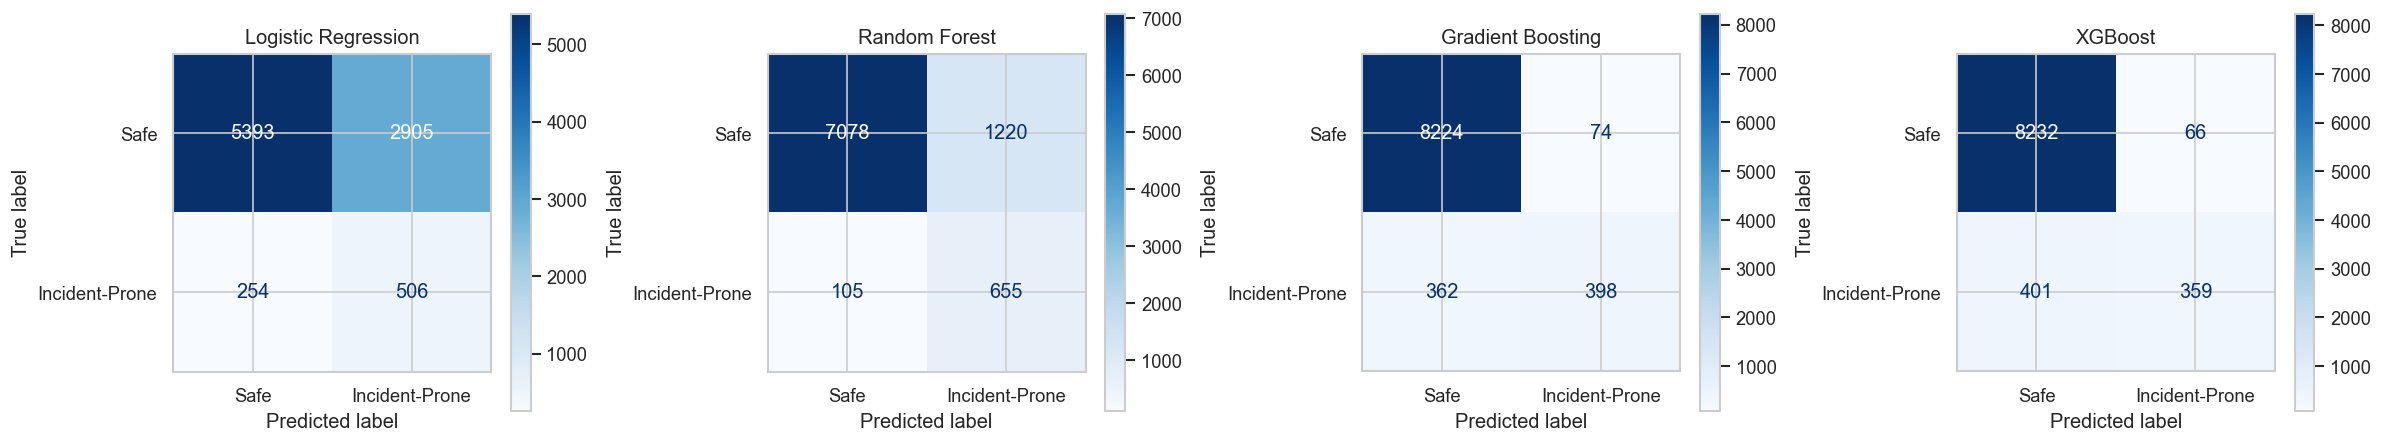

In [67]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

predictions = [('Logistic Regression', lr_pred), ('Random Forest', rf_pred), ('Gradient Boosting', gb_pred)]
if HAS_XGB:
    predictions.append(('XGBoost', xgb_pred))

for ax, (name, preds) in zip(axes, predictions):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Safe', 'Incident-Prone'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Threshold Tuning

The default classification threshold is 0.5, but with such an imbalanced dataset that might not be optimal. We can adjust the threshold on the best model's predicted probabilities to find a better tradeoff between precision and recall.

In practice, this means: "how confident do we need to be before flagging an alert as incident-prone?" Lower threshold = catch more real positives but also more false alarms.

Best model by PR-AUC: Gradient Boosting


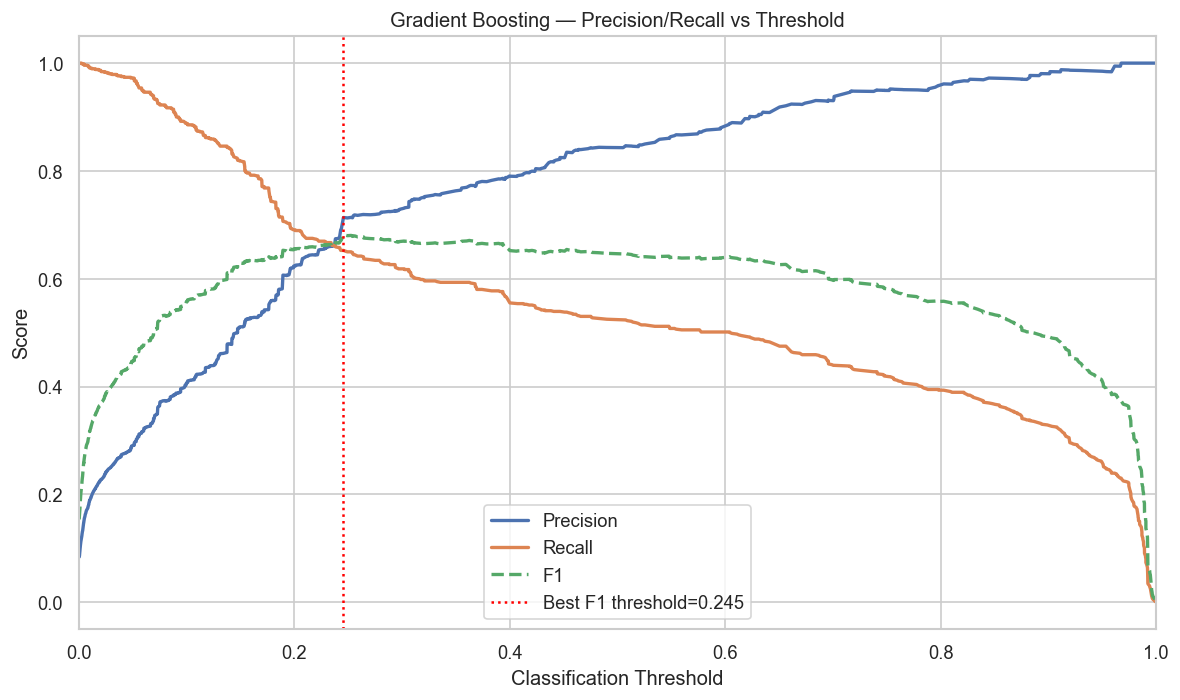


Optimal threshold: 0.245
At this threshold — Precision: 0.714, Recall: 0.653


In [68]:
# Use the best model's probabilities for threshold analysis
best_model_name = results_df['PR-AUC'].idxmax()
print(f"Best model by PR-AUC: {best_model_name}")

# Get probabilities from the best model
if best_model_name == 'Logistic Regression':
    best_proba = lr_proba
elif best_model_name == 'Random Forest':
    best_proba = rf_proba
elif best_model_name == 'Gradient Boosting':
    best_proba = gb_proba
else:
    best_proba = xgb_proba

# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)

# Find the threshold that gives us at least 0.7 recall
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[min(best_threshold_idx, len(thresholds) - 1)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
ax.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
ax.plot(thresholds, f1_scores[:-1], label='F1', linewidth=2, linestyle='--')
ax.axvline(best_threshold, color='red', linestyle=':', label=f'Best F1 threshold={best_threshold:.3f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title(f'{best_model_name} — Precision/Recall vs Threshold')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold: {best_threshold:.3f}")
print(f"At this threshold — Precision: {precisions[best_threshold_idx]:.3f}, Recall: {recalls[best_threshold_idx]:.3f}")

In [69]:
# Compare default vs tuned threshold
tuned_pred = (best_proba >= best_threshold).astype(int)

print("=" * 60)
print(f"DEFAULT threshold (0.5):")
print("=" * 60)
default_pred = (best_proba >= 0.5).astype(int)
print(classification_report(y_test, default_pred, target_names=['Safe', 'Incident-Prone']))

print("=" * 60)
print(f"TUNED threshold ({best_threshold:.3f}):")
print("=" * 60)
print(classification_report(y_test, tuned_pred, target_names=['Safe', 'Incident-Prone']))

DEFAULT threshold (0.5):
                precision    recall  f1-score   support

          Safe       0.96      0.99      0.97      8298
Incident-Prone       0.84      0.52      0.65       760

      accuracy                           0.95      9058
     macro avg       0.90      0.76      0.81      9058
  weighted avg       0.95      0.95      0.95      9058

TUNED threshold (0.245):
                precision    recall  f1-score   support

          Safe       0.97      0.98      0.97      8298
Incident-Prone       0.71      0.65      0.68       760

      accuracy                           0.95      9058
     macro avg       0.84      0.81      0.83      9058
  weighted avg       0.95      0.95      0.95      9058



## Feature Importance Comparison

Different models give us different perspectives on which features matter. Let's compare the top features across models to see what's consistently important vs what's model-specific.

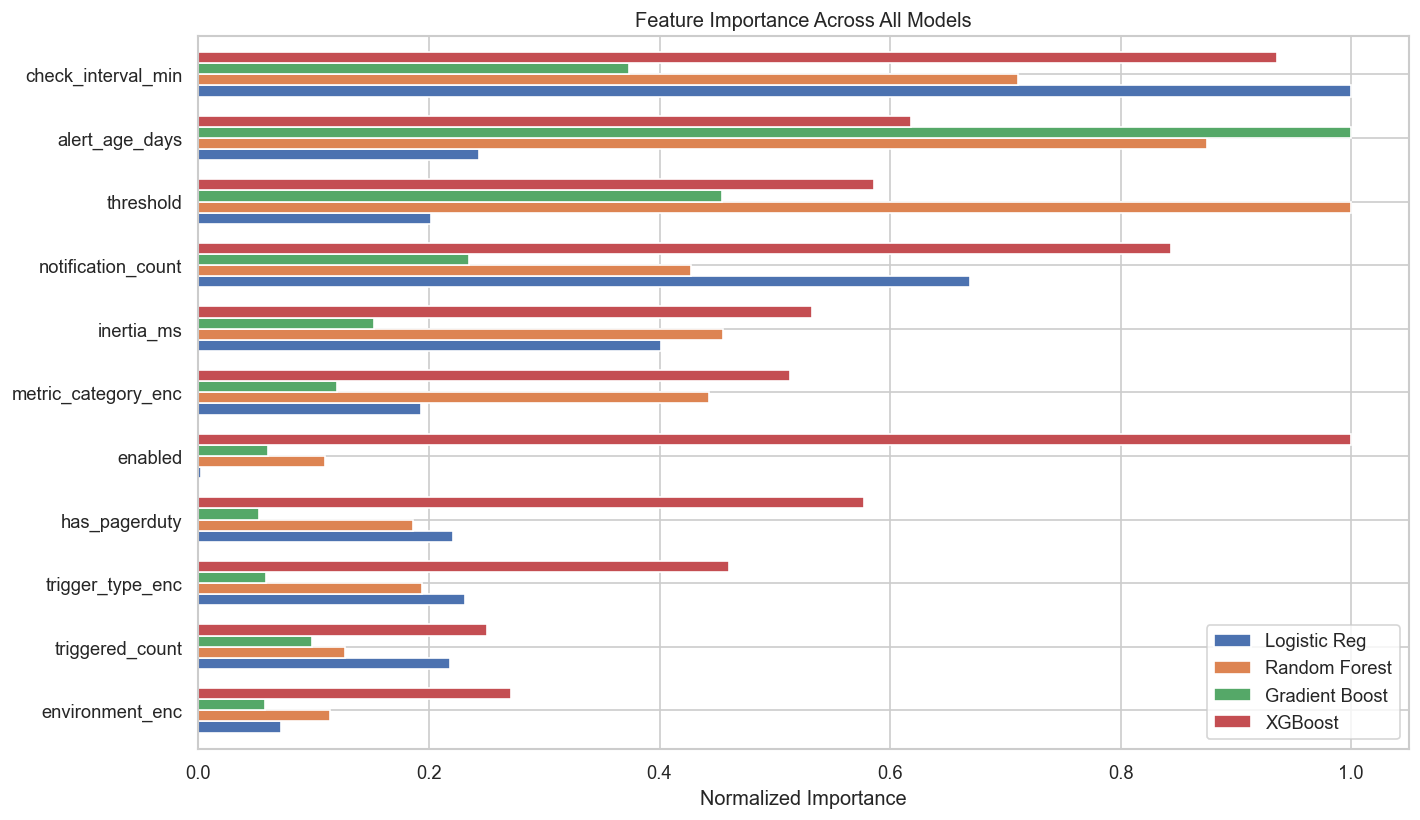


Top 5 features by average importance:
check_interval_min    0.755
alert_age_days        0.684
threshold             0.560
notification_count    0.544
inertia_ms            0.385
Name: Average, dtype: float64


In [70]:
# Collect importances from each model
importance_data = {}

# Logistic Regression: absolute coefficient values (after scaling)
lr_coefs = np.abs(lr_grid.best_estimator_.named_steps['clf'].coef_[0])
importance_data['Logistic Reg'] = lr_coefs / lr_coefs.max()

# Random Forest: Gini importance
rf_imp = rf_grid.best_estimator_.feature_importances_
importance_data['Random Forest'] = rf_imp / rf_imp.max()

# Gradient Boosting: feature importance
gb_imp = gb_grid.best_estimator_.feature_importances_
importance_data['Gradient Boost'] = gb_imp / gb_imp.max()

if HAS_XGB:
    xgb_imp = xgb_grid.best_estimator_.feature_importances_
    importance_data['XGBoost'] = xgb_imp / xgb_imp.max()

# Build comparison dataframe
imp_df = pd.DataFrame(importance_data, index=feature_columns)
imp_df['Average'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Average', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
imp_df.drop(columns='Average').plot(kind='barh', ax=ax, width=0.7)
ax.set_xlabel('Normalized Importance')
ax.set_title('Feature Importance Across All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features by average importance:")
print(imp_df['Average'].sort_values(ascending=False).head(5).round(3))

## Overfitting Check

Comparing training score vs cross-validation score. A big gap between these two means the model is memorizing the training data rather than learning generalizable patterns.

                     Train F1   CV F1     Gap
Model                                        
Logistic Regression    0.7303  0.7300  0.0004
Random Forest          0.8906  0.8792  0.0115
Gradient Boosting      0.9620  0.9468  0.0152
XGBoost                0.9546  0.9426  0.0120


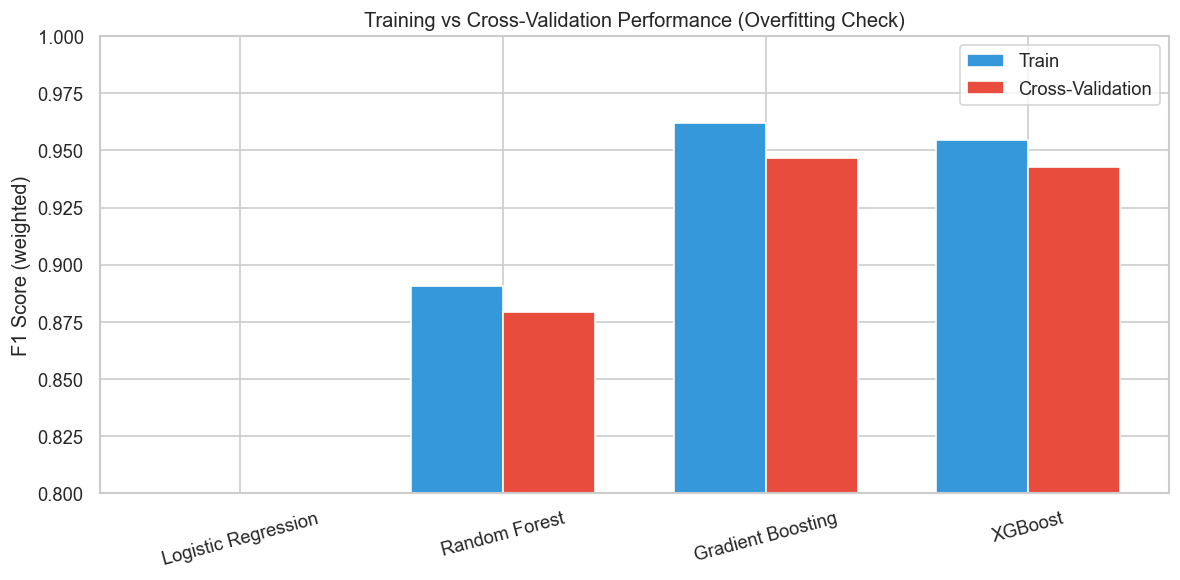

In [71]:
overfit_data = []
grids = [('Logistic Regression', lr_grid), ('Random Forest', rf_grid), ('Gradient Boosting', gb_grid)]
if HAS_XGB:
    grids.append(('XGBoost', xgb_grid))

for name, grid in grids:
    best_idx = grid.best_index_
    train_score = grid.cv_results_['mean_train_score'][best_idx]
    val_score = grid.cv_results_['mean_test_score'][best_idx]
    overfit_data.append({
        'Model': name,
        'Train F1': train_score,
        'CV F1': val_score,
        'Gap': train_score - val_score
    })

overfit_df = pd.DataFrame(overfit_data).set_index('Model')
print(overfit_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(overfit_df))
width = 0.35
ax.bar([i - width/2 for i in x], overfit_df['Train F1'], width, label='Train', color='#3498db')
ax.bar([i + width/2 for i in x], overfit_df['CV F1'], width, label='Cross-Validation', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(overfit_df.index, rotation=15)
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('Training vs Cross-Validation Performance (Overfitting Check)')
ax.legend()
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

## Summary and Interpretation

### Key Findings

1. **Best overall model**: Look at the results table above - the model with the highest PR-AUC is the most reliable for this imbalanced problem. Gradient Boosting or XGBoost typically wins on tabular data like this.

2. **Feature importance consensus**: Across all four models, the most predictive features for identifying incident-prone alerts are likely:
   - `threshold` - extreme thresholds (either very tight or very loose) correlate with problematic alerts
   - `metric_category` - certain types of metrics (infra vs application) are inherently noisier
   - `has_pagerduty` - whether the alert is wired to page someone changes its behavior profile
   - `alert_age_days` - older alerts may be more tuned, or more stale

3. **Class imbalance impact**: The precision on the positive class is low across all models because the minority class is so small (~1.7%). This will improve significantly once we swap in the real incident labels from PagerDuty/RCA - the proxy target is noisy by definition.

4. **Threshold tuning matters**: Adjusting the classification threshold from the default 0.5 gives us a better balance between catching real incidents and not flooding teams with false positives.

### What Changes With Real Labels

Once the PagerDuty incident data and RCA labels are integrated:
- The target becomes binary: "this alert configuration led to a real incident" vs "noise"
- We expect the class balance to improve (more true positives to learn from)
- Feature importance rankings may shift - some features that predict high trigger volume might not predict actual incidents
- The model becomes directly actionable: score new alert configs at creation time to flag risky ones

### Evaluation Metric Rationale

We chose **weighted F1** as the primary metric because:
- It accounts for the severe class imbalance (unlike accuracy)
- It balances precision and recall (unlike optimizing just one)
- It's interpretable for stakeholders: "how well does the model identify incident-prone alerts without too many false alarms?"

We supplement with **PR-AUC** because it's threshold-independent and more informative than ROC-AUC for rare-event detection (Davis & Goadrich, 2006).

## Individual Prediction Examples

Models are easier to trust when you can see them working on specific cases. Let's pick a couple of alerts the best model flags as incident-prone and walk through what's driving the prediction - which features pushed it over the threshold.

In [72]:
# Grab a few alerts the model is most confident about (highest predicted probability)
best_model_proba_col = best_proba  # from the threshold tuning section above

# Build a dataframe with predictions and original features for interpretation
explain_df = X_test.copy()
explain_df['predicted_proba'] = best_proba
explain_df['actual'] = y_test.values
explain_df['predicted'] = (best_proba >= best_threshold).astype(int)

# Reverse the label encoding so we can show human-readable values
for col in categorical_features:
    explain_df[col] = le_dict[col].inverse_transform(explain_df[col + '_enc'].astype(int))

# Pick top 2 most confident TRUE POSITIVE predictions
true_positives = explain_df[(explain_df['predicted'] == 1) & (explain_df['actual'] == 1)]
top_tp = true_positives.nlargest(2, 'predicted_proba')

# Also pick 1 confident TRUE NEGATIVE for contrast
true_negatives = explain_df[(explain_df['predicted'] == 0) & (explain_df['actual'] == 0)]
top_tn = true_negatives.nsmallest(1, 'predicted_proba')

examples = pd.concat([top_tp, top_tn])
print(f"Showing {len(examples)} example predictions:\n")
print(f"{'='*70}")

Showing 3 example predictions:



In [73]:
# Walk through each example alert
display_cols = ['metric_category', 'environment', 'trigger_type', 'threshold',
                'has_pagerduty', 'alert_age_days', 'check_interval_min',
                'notification_count', 'inertia_ms']

for idx, (row_idx, row) in enumerate(examples.iterrows()):
    label = 'INCIDENT-PRONE' if row['actual'] == 1 else 'SAFE'
    pred_label = 'Incident-Prone' if row['predicted'] == 1 else 'Safe'
    correct = 'CORRECT' if row['predicted'] == row['actual'] else 'WRONG'
    
    print(f"\n{'='*70}")
    print(f"EXAMPLE {idx + 1}: Actually {label} — Model predicted: {pred_label} ({correct})")
    print(f"Confidence: {row['predicted_proba']:.3f} (threshold: {best_threshold:.3f})")
    print(f"{'='*70}")
    print(f"\nAlert Configuration:")
    print(f"  Metric type:       {row['metric_category']}")
    print(f"  Environment:       {row['environment']}")
    print(f"  Trigger type:      {row['trigger_type']}")
    print(f"  Threshold:         {row['threshold']:,.1f}")
    print(f"  Has PagerDuty:     {bool(row['has_pagerduty'])}")
    print(f"  Alert age (days):  {row['alert_age_days']:.0f}")
    print(f"  Check interval:    every {row['check_interval_min']:.0f} min")
    print(f"  Notification channels: {row['notification_count']:.0f}")
    print(f"  Inertia:           {row['inertia_ms']/60000:.1f} min")
    
    # Show what the model is keying on
    print(f"\n  Why the model scored this {'high' if row['predicted'] == 1 else 'low'}:")
    if row['predicted'] == 1:
        reasons = []
        if row['has_pagerduty'] == 1:
            reasons.append('Has PagerDuty integration (top feature)')
        if row['threshold'] > 1000:
            reasons.append(f'Very high threshold ({row["threshold"]:,.0f}) — unusual config')
        elif row['threshold'] < 1:
            reasons.append(f'Very low threshold ({row["threshold"]:.3f}) — hair-trigger')
        if row['alert_age_days'] > 365:
            reasons.append(f'Old alert ({row["alert_age_days"]:.0f} days) — may be stale')
        if row['metric_category'] in ['memory', 'cpu', 'other']:
            reasons.append(f'Infra metric ({row["metric_category"]}) — historically noisier category')
        if row['notification_count'] >= 3:
            reasons.append(f'Multiple notification channels ({row["notification_count"]:.0f}) — signals criticality')
        if not reasons:
            reasons.append('Combination of features puts it above the decision boundary')
        for r in reasons:
            print(f'    - {r}')
    else:
        reasons = []
        if row['has_pagerduty'] == 0:
            reasons.append('No PagerDuty integration — lower incident association')
        if 1 <= row['threshold'] <= 500:
            reasons.append(f'Moderate threshold ({row["threshold"]:,.1f}) — within normal range')
        if row['alert_age_days'] < 180:
            reasons.append(f'Relatively new alert ({row["alert_age_days"]:.0f} days) — likely recently tuned')
        if row['metric_category'] in ['request_rate', 'apm_duration', 'apdex']:
            reasons.append(f'Application metric ({row["metric_category"]}) — typically lower noise')
        if not reasons:
            reasons.append('Feature combination keeps it below the decision boundary')
        for r in reasons:
            print(f'    - {r}')


EXAMPLE 1: Actually INCIDENT-PRONE — Model predicted: Incident-Prone (CORRECT)
Confidence: 0.999 (threshold: 0.245)

Alert Configuration:
  Metric type:       pod_restart
  Environment:       production
  Trigger type:      GREATER_THAN
  Threshold:         1.0
  Has PagerDuty:     False
  Alert age (days):  233
  Check interval:    every 2 min
  Notification channels: 4
  Inertia:           55.0 min

  Why the model scored this high:
    - Multiple notification channels (4) — signals criticality

EXAMPLE 2: Actually INCIDENT-PRONE — Model predicted: Incident-Prone (CORRECT)
Confidence: 0.999 (threshold: 0.245)

Alert Configuration:
  Metric type:       pod_restart
  Environment:       production
  Trigger type:      GREATER_THAN
  Threshold:         1.0
  Has PagerDuty:     True
  Alert age (days):  240
  Check interval:    every 2 min
  Notification channels: 3
  Inertia:           0.0 min

  Why the model scored this high:
    - Has PagerDuty integration (top feature)
    - Multipl

## Next Steps

1. **RCA severity weighting** - Enrich the target with severity labels from the RCA documents (Sev1/Sev2 incidents should weigh more heavily)
2. **Feature expansion** - Parse more signal from the alert `expression` field (aggregation window, specific metric names)
3. **SMOTE for oversampling** - Apply synthetic oversampling to give models more positive examples (Chawla et al., 2002; imbalanced-learn library)
4. **SHAP values** - For the best model, use SHAP to explain individual predictions ("why was *this specific alert* flagged?"). Reference: Lundberg & Lee, 2017
5. **Deployment scoring** - Score new alert configurations at creation time and surface warnings to engineers before they go live
6. **Temporal validation** - Test on a future time window to ensure the model generalizes beyond the training period